In [1]:
# 导入数据
import pandas as pd
from bs4 import BeautifulSoup

# 加载CSV文件到Pandas DataFrame
try:
    df = pd.read_csv('/home/gaojiayu/wb_project/data/postings.csv')
    print("数据加载成功！")
    print(f"数据集包含 {df.shape[0]} 行和 {df.shape[1]} 列。")
except FileNotFoundError:
    print("错误: 文件未找到。请确保文件名和路径正确。")

数据加载成功！
数据集包含 123849 行和 31 列。


In [2]:
# 职位标题（'title'）和职位描述（'description'）通常都包含关键信息。将它们合并成一个新列 full_text
title_col = 'title'
description_col = 'description'

# 合并前，先处理这两列可能存在的缺失值，填充为空字符串
df[title_col] = df[title_col].fillna('')
df[description_col] = df[description_col].fillna('')

# 将标题和描述合并成一个新列 'full_text'，用空格隔开
df['full_text'] = df[title_col] + ' : ' + df[description_col]

print("已成功创建 'full_text' 列。")
df[['title', 'description', 'full_text']].head()

已成功创建 'full_text' 列。


,title,description,full_text
0,Marketing Coordinator,Job descriptionA leading real estate firm in N...,Marketing Coordinator : Job descriptionA leadi...
1,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",Mental Health Therapist/Counselor : At Aspen T...
2,Assitant Restaurant Manager,The National Exemplar is accepting application...,Assitant Restaurant Manager : The National Exe...
3,Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,Senior Elder Law / Trusts and Estates Associat...
4,Service Technician,Looking for HVAC service tech with experience ...,Service Technician : Looking for HVAC service...


In [3]:
# 清洗数据
def clean_html(text):
    # 确保输入是字符串类型
    if not isinstance(text, str):
        return ""
    return BeautifulSoup(text, "html.parser").get_text(separator=" ")

# 创建一个新列 'cleaned_text' 来存储清洗后的文本
df['cleaned_text'] = df['full_text'].apply(clean_html)

print("HTML 清洗完成，结果已存入 'cleaned_text' 列。")

HTML 清洗完成，结果已存入 'cleaned_text' 列。


In [4]:
sample_size = 200
df_sample = df.sample(n=sample_size, random_state=42)

print(f"已成功抽取 {len(df_sample)} 条数据作为样本。")

已成功抽取 200 条数据作为样本。


In [ ]:
# 确保 pandas 和 tqdm 已导入
import pandas as pd
from tqdm import tqdm
import time

# 从 main.py 导入编写的函数
try:
    from main import create_prompt_v1, classify_with_llm

    print("函数导入成功！")
except ImportError:
    print(
        "错误：无法从 main.py 导入函数。请确保 main.py 文件在同一目录下且没有语法错误。"
    )

# 注册tqdm到pandas，这样我们就可以使用 .progress_apply()
tqdm.pandas(desc="职位分类进度")

# 定义一个封装函数，将 prompt 生成和 API 调用合二为一
def classify_job_description(text: str) -> str:
    """对单个职位描述进行分类的完整流程"""
    if pd.isna(text) or not text.strip():
        return "文本为空"  # 处理空文本的边缘情况

    # 1. 创建 Prompt
    prompt = create_prompt_v1(text)

    time.sleep(3)

    # 2. 调用 LLM 进行分类
    category = classify_with_llm(prompt, 5)

    return category

# 对 df['cleaned_text'] 列的每一行应用分类函数
# .progress_apply 会显示一个漂亮的进度条
df_sample["llm_category_v1"] = df_sample["cleaned_text"].progress_apply(
    classify_job_description
)

# 显示处理后的结果
print("\n分类完成！")
print("查看带有新分类列的DataFrame前几行：")
display(df_sample[["cleaned_text", "llm_category_v1"]].head())

# 查看分类结果的分布情况
print("\n各类别职位数量分布：")
print(df_sample["llm_category_v1"].value_counts())

In [ ]:
# 确保 df_sample 已经包含了 llm_category_v1 列
# 从200条样本中，再随机抽取50条作为验证集
validation_size = 50
df_val = df_sample.sample(n=validation_size, random_state=101) # 使用新的 random_state

print(f"已成功抽取 {len(df_val)} 条数据作为验证集。")
df_val.head()

已成功抽取 50 条数据作为验证集。


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips,full_text,cleaned_text,llm_category_v1
37400,3895809104,DaVita Kidney Care,Patient Care Technician,"124 Fire Tower Rd, Orangeburg, South Carolina,...",NaN,NaN,"Orangeburg, SC",6487.0,4.0,NaN,...,0,FULL_TIME,NaN,NaN,NaN,29115.0,45075.0,"Patient Care Technician : 124 Fire Tower Rd, O...","Patient Care Technician : 124 Fire Tower Rd, O...",others
58875,3901955645,Rhodes College,Visiting Assistant Professor of Psychology,Job Title:\n\nVisiting Assistant Professor of ...,NaN,NaN,"Memphis, TN",20720.0,4.0,NaN,...,0,FULL_TIME,NaN,NaN,NaN,38103.0,47157.0,Visiting Assistant Professor of Psychology : J...,Visiting Assistant Professor of Psychology : J...,Education & Research
90252,3904421345,CGI,R Developer - Technical Lead,Position Description\n\nThis is an opportunity...,202700.0,YEARLY,"Plymouth Meeting, PA",1415.0,6.0,NaN,...,0,FULL_TIME,USD,BASE_SALARY,139500.0,19462.0,42091.0,R Developer - Technical Lead : Position Descri...,R Developer - Technical Lead : Position Descri...,"Engineering, Data & AI"
102553,3905283685,North American Dental Group (NADG),Front Desk Coordinator,“Open Up” To A Whole New Dental Experience\n\n...,NaN,NaN,"Palm Bay, FL",2831596.0,2.0,NaN,...,0,PART_TIME,NaN,NaN,NaN,32905.0,12009.0,Front Desk Coordinator : “Open Up” To A Whole ...,Front Desk Coordinator : “Open Up” To A Whole ...,Corporate & Ops
9274,3886476972,myGwork - LGBTQ+ Business Community,Commercial Card Relationship Manager - Payment...,This inclusive employer is a member of myGwork...,NaN,NaN,"Elgin, IL",5240076.0,5.0,NaN,...,0,FULL_TIME,NaN,NaN,NaN,60120.0,17089.0,Commercial Card Relationship Manager - Payment...,Commercial Card Relationship Manager - Payment...,Marketing & Sales


In [ ]:
# 选择需要的列并导出到CSV
columns_to_export = ['cleaned_text', 'llm_category_v1']
validation_file_path = 'validation_set_for_annotation.csv'
df_val[columns_to_export].to_csv(validation_file_path, index=False, encoding='utf-8-sig')

print(f"待标注文件已导出到: {validation_file_path}")
print("请打开此文件，新增一列 'manual_category' 并完成人工分类。")

In [10]:
# 读回包含“黄金标准”的数据
import pandas as pd

annotated_file_path = 'validation_set_for_annotation_50.csv'
try:
    df_val_annotated = pd.read_csv(annotated_file_path)
    print("成功读回已标注的验证集！")
    display(df_val_annotated.head())
except FileNotFoundError:
    print(f"错误: 未找到文件 '{annotated_file_path}'。请确保已完成标注并正确保存了文件。")

成功读回已标注的验证集！


cleaned_text  \
0                                                                                                                                                                                           Patient Care Technician : 124 Fire Tower Rd, Orangeburg, South Carolina, 29118, United States of America\n\nDaVita is seeking a Patient Care Technician who is looking to give life in an outpatient dialysis center. You can make an exceptional difference in the lives of our patients and their families dealing with end-stage renal failure or chronic kidney disease. Do you desire to deliver care in an empathetic, compassionate way - the way you'd want your own care to be?\n\nIf you haven't considered Nephrology before, read on as we think that you should.\n\nJoining DaVita as Patient Care Technician (PCT) is an exciting opportunity to jump start your career in the health care industry! With paid, extensive training, you will gain the skills needed to care for our patients and build a network of other health care professionals across the geography where you live. Once you have successfully completed training, you will join a holistic team of care professionals – including nurses, dietitian, social workers, and other experienced PCTs – to care for our patients. It's not a job, it's giving life and a career based on passion and purpose.\n\nDaVita – which is Italian for "giving life" – is working to provide quality service to patients, partners, and teammates. Our mission is to be the Provider, Partner, and Employer of Choice.\n\nOur PCTs also find DaVita professionally fulfilling. To help advance your career, we offer clear paths to higher levels of responsibility and compensation through our Clinical Ladders program. Through DaVita's Bridge to your Dreams program, teammates who have been in their role for six consecutive months and in good standing, are eligible to receive tuition assistance up front to pursue their dream of becoming a DaVita RN and getting their Associates Degree in Nursing. We also have dedicated training to become a Facility Administrator, and training to become a Regional Operations Director. Your success is driven by your performance and desire.\n\nSome details about this position:\n\nNo Dialysis experience is required.Training may take place in a facility or a training clinic other than your assigned home clinicPotential to float to various clinics during and after your trainingYou must have a flexible schedule and be able to work mornings, evenings, weekends, and holidays\n\nWhat you can expect:\n\nDirect Patient Care. Spend the majority of your day in direct one-on-one patient care to provide safe, comfortable and hygienic dialysis treatment.Our PCTs care for multiple patients.Technician Duties. To monitor patients before, during and after dialysis treatment including measuring and recording stats, patient observations, and hemodialysis machine setup. Please note you will have exposure to blood and needles.Building long-term relationships with your patients who are suffering from end stage renal disease and are receiving treatment on average 3 times/week. You will also be responsible for educating patients on Kidney Dialysis related topics.Team. Cross functional team of clinicians including technicians, nurses, dietitians, social workers and leadership. PCTs work under the supervision of a RN.\n\nWhat we'll provide:\n\nDaVita Rewards package connects teammates to what matters most including:\n\nComprehensive benefits: Medical, dental, vision, 401(k) match, paid time off, PTO cash outSupport for you and your family: family resources, EAP counseling sessions, access Headspace®, backup child and elder care, maternity/paternity leave, pet insurance, and morePaid training\n\nRequirements:\n\nDesire to enter the health care field to care for other people in needHigh school diploma or equivalentMust be comfortable working around blood and needlesMust be comfortable mixing acid or bicarbPhysical and mental ability t

In [3]:
# 计算v1正确率
# 确保两列都存在
if 'llm_category_v1' in df_val_annotated.columns and 'manual_category' in df_val_annotated.columns:
    # 计算准确率
    accuracy_v1 = (df_val_annotated['llm_category_v1'] == df_val_annotated['manual_category']).mean()

    print(f"Prompt V1 在50条验证集上的准确率是: {accuracy_v1:.2%}")
else:
    print("错误: 缺少 'llm_category_v1' 或 'manual_category' 列。")

Prompt V1 在50条验证集上的准确率是: 82.00%


In [4]:
# 筛选出模型预测错误的所有行
error_cases_v1 = df_val_annotated[df_val_annotated['llm_category_v1'] != df_val_annotated['manual_category']]

print(f"V1版本共分类错误 {len(error_cases_v1)} 条。错误案例如下：")

# 设置pandas显示选项，以完整显示文本内容
pd.set_option('display.max_colwidth', None)

# 显示错误案例，以便分析
display(error_cases_v1[['cleaned_text', 'manual_category', 'llm_category_v1']])

V1版本共分类错误 9 条。错误案例如下：


cleaned_text  \
7                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              CUSTOMER SERVICE REPRESENTATIVE : Store Family Dollar\n\nFamily Dollar is seeking motivated individuals to support our Stores as we provide essential products at great values to the communities we serve.\n\nGeneral Summary\n\nAs a Family Dollar Customer Service Representative you will be responsible for providing exceptional service to our customers. Key priorities include greeting customers, assisting them with selection of merchandise, completing transactions, and answering questions regarding the store and merchandise.\n\nPrinciple Duties and Responsibilities: \n\n Provides customer engagement in positive and approachable manner. Assists in maintaining a clean, well-stocked store for customers during their shopping experience. Helps in the unloading of merchandise from delivery trucks, organizes merchandise, and transports merchandise from stockroom to sales floor. Independently stocks shelves and recovers merchandise in the store. Accurately h

In [8]:
# 更新prompt-v2
from tqdm import tqdm
import time
# 从 main.py 导入编写的函数
try:
    from main import create_prompt_v2, classify_with_llm

    print("函数导入成功！")
except ImportError:
    print(
        "错误：无法从 main.py 导入函数。请确保 main.py 文件在同一目录下且没有语法错误。"
    )

# 定义一个新的包装函数来使用 V2 prompt
def classify_job_description_v2(text: str) -> str:
    if pd.isna(text) or not text.strip():
        return "文本为空"
    prompt = create_prompt_v2(text)
    time.sleep(3)
    category = classify_with_llm(prompt, 5)  # 核心API调用函数保持不变
    return category

# 注册tqdmtext
tqdm.pandas(desc="V2 分类进度")

# **只对验证集** 运行 V2 分类，并将结果存入新列
df_val_annotated["llm_category_v2"] = df_val_annotated["cleaned_text"].progress_apply(
    classify_job_description_v2
)
print("V2 分类完成！")

columns_to_export = ['cleaned_text','manual_category','llm_category_v1','llm_category_v2']
validation_file_path = 'validation_set_for_annotation_v1+v2_50.csv'
df_val_annotated[columns_to_export].to_csv(validation_file_path, index=False, encoding='utf-8-sig')
print(f"文件已导出到: {validation_file_path}")

函数导入成功！


V2 分类进度:  10%|█         | 5/50 [01:22<13:28, 17.96s/it]

速率受限，等待 2 秒后重试...
速率受限，等待 3 秒后重试...


V2 分类进度:  16%|█▌        | 8/50 [02:32<15:46, 22.54s/it]

速率受限，等待 2 秒后重试...


...

速率受限，等待 2 秒后重试...


V2 分类进度: 100%|██████████| 50/50 [22:54<00:00, 20.09s/it]

速率受限，等待 2 秒后重试...
速率受限，等待 3 秒后重试...
速率受限，等待 5 秒后重试...


V2 分类进度: 100%|██████████| 50/50 [23:27<00:00, 28.14s/it]

V2 分类完成！
文件已导出到: validation_set_for_annotation_v1+v2_50.csv


In [9]:
# 计算 V2 准确率
accuracy_v2 = (df_val_annotated['llm_category_v2'] == df_val_annotated['manual_category']).mean()

print(f"Prompt V1 在验证集上的准确率是: {accuracy_v1:.2%}")
print(f"Prompt V2 在验证集上的准确率是: {accuracy_v2:.2%}")

# 查看V1和V2的对比结果
print("\n--- V1 与 V2 结果对比 ---")
display(df_val_annotated[['cleaned_text', 'manual_category', 'llm_category_v1', 'llm_category_v2']])

Prompt V1 在验证集上的准确率是: 82.00%
Prompt V2 在验证集上的准确率是: 94.00%

--- V1 与 V2 结果对比 ---


cleaned_text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  Patient Care Technician : 124 Fire Tower Rd, Orangeburg, South Carolina, 29118, United States of America\n\nDaVita is seeking a Patient Care Technician who is looking to give life in an outpatient dialysis center. You can make an exceptional difference in the lives of our patients and their families dealing with end-stage renal failure or chronic kidney disease. Do you desire to deliver care in an empathetic, compassionate way - the way you'd want your own care to be?\n\nIf you haven't considered Nephrology before, read on as we think that you should.\n\nJoining DaVita as Patient Care Technician (PCT) is an exciting opportunity to jump start your career in the health care industry! With paid, extensive training, you will gain the skills needed to care for our patients and build a network of other health care professionals across the geography where you live. Once you have successf

In [ ]:
from tqdm import tqdm
import time
# 从 main.py 导入新编写的函数
try:
    from main import extract_skills_with_llm
    print("技能提取函数导入成功！")
except (ImportError, NameError):
    print("错误：无法从 main.py 导入新函数。请确保函数已保存且无误，并考虑重启内核。")


# 定义一个带延迟的包装函数
def safe_extract(text):
    result = extract_skills_with_llm(text)
    # 强制等待 8 秒，确保每分钟请求不超过 8 次 (60/8 = 7.5)
    time.sleep(8) 
    return result

tqdm.pandas(desc="技能提取进度")

# 对 df_sample['cleaned_text'] 列的每一行应用技能提取函数
# 在完整的200条样本上运行，以获得更多结果
df_sample['llm_extracted_skills'] = df_sample['cleaned_text'].progress_apply(safe_extract)

# 显示处理后的结果
print("\n技能提取完成！")
print("查看带有提取技能列的DataFrame：")

# 为了更好地展示，只看那些成功提取出技能的行
extracted_df = df_sample[df_sample['llm_extracted_skills'].apply(lambda x: len(x) > 0)]

display(extracted_df[['cleaned_text', 'llm_extracted_skills']].head())

print(f"\n在 {len(df_sample)} 条样本中，有 {len(extracted_df)} 条成功提取出了至少一项技能。")

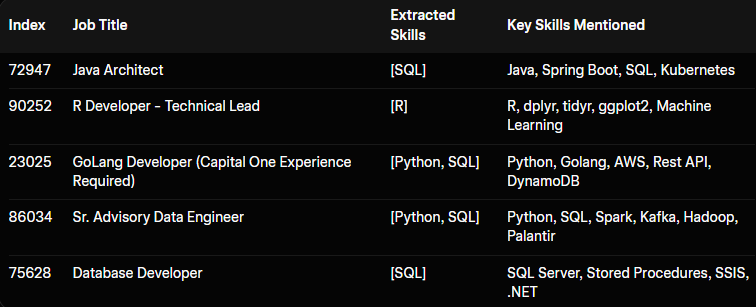